In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.datasets import cifar10
from scipy.ndimage import gaussian_filter
from sklearn.decomposition import PCA
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [2]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
class_names = ["airplane","automobile","bird","cat","deer",
               "dog","frog","horse","ship","truck"]

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 270s 2us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


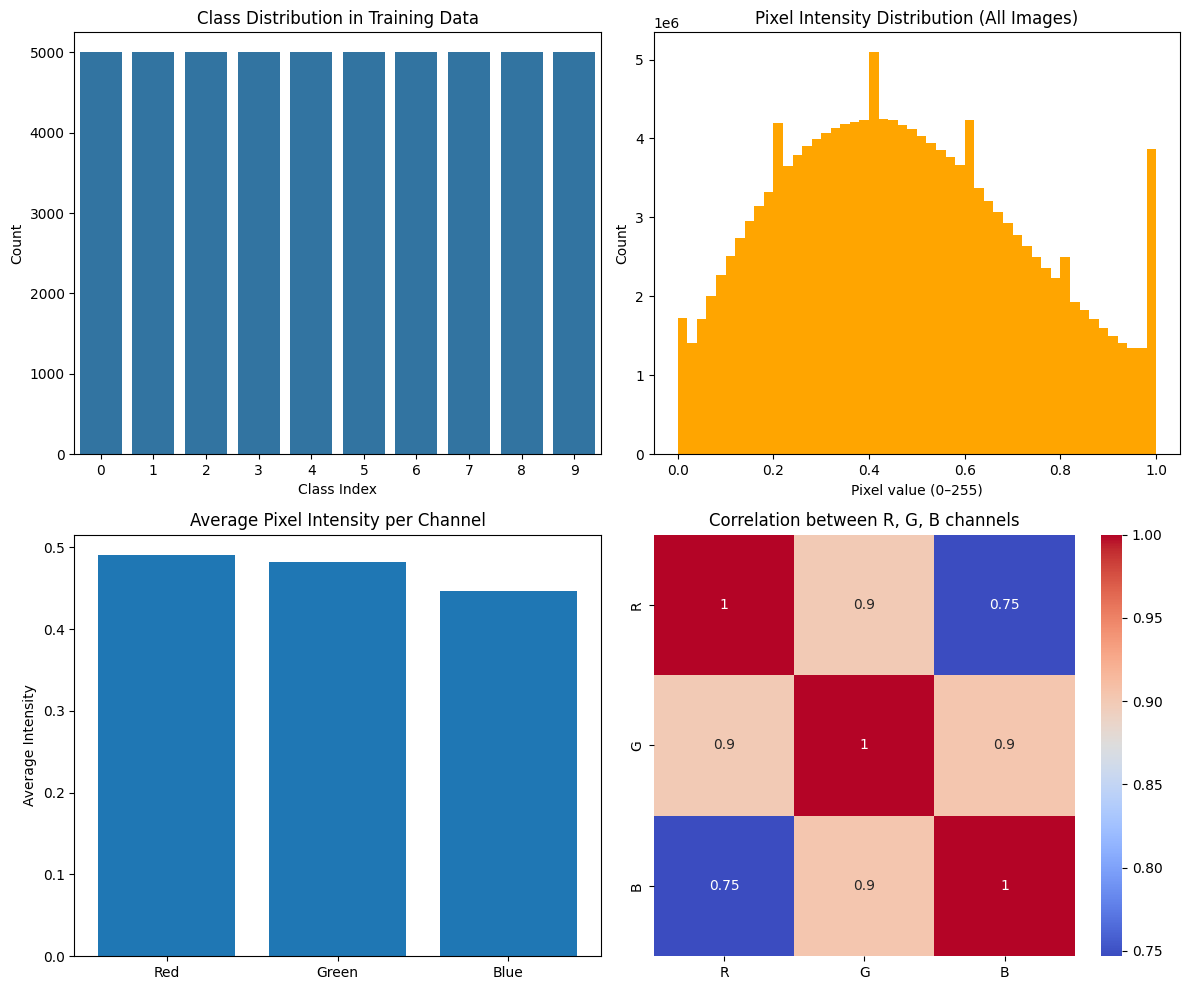

In [64]:
# EDA
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes = axes.flatten()

# Class distribution
sns.countplot(x=y_train.flatten(), ax=axes[0])
axes[0].set_title("Class Distribution in Training Data")
axes[0].set_xlabel("Class Index")
axes[0].set_ylabel("Count")


# Pixel intensity histogram
axes[1].hist(x_train.flatten(), bins=50, color="orange")
axes[1].set_title("Pixel Intensity Distribution (All Images)")
axes[1].set_xlabel("Pixel value (0–255)")
axes[1].set_ylabel("Count")


# Color channel mean distribution
channel_means = x_train.mean(axis=(0,1,2))
axes[2].bar(["Red","Green","Blue"], channel_means)
axes[2].set_title("Average Pixel Intensity per Channel")
axes[2].set_ylabel("Average Intensity")


# Channel correlation
corr = np.corrcoef([x_train[:1000,:,:,i].flatten() for i in range(3)])
sns.heatmap(corr, annot=True, xticklabels=["R","G","B"], yticklabels=["R","G","B"], cmap="coolwarm", ax=axes[3])
axes[3].set_title("Correlation between R, G, B channels")


plt.tight_layout()
plt.show()



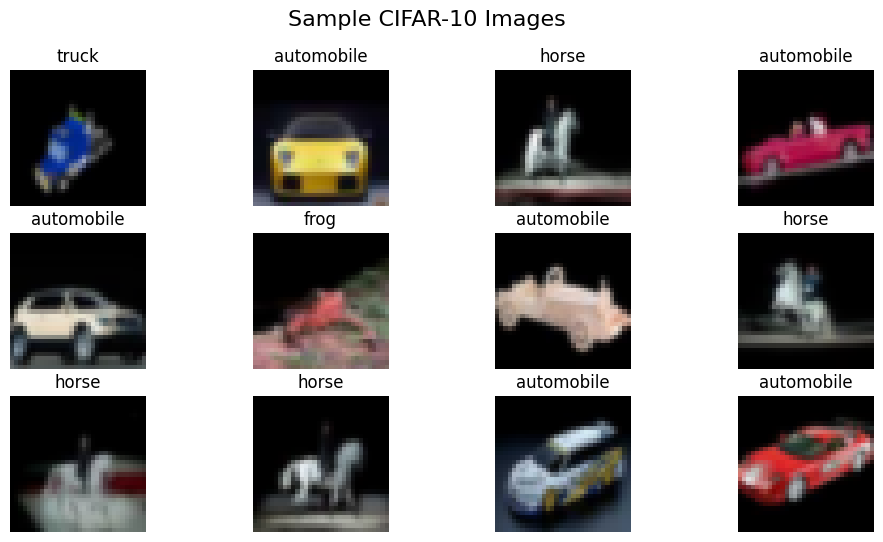

In [65]:
# Display sample CIFAR-10 images
plt.figure(figsize=(12, 6))
for i in range(12):
    plt.subplot(3, 4, i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.suptitle("Sample CIFAR-10 Images", fontsize=16)
plt.show()

In [4]:
# a) Remove duplicates
unique_train, unique_idx = np.unique(x_train.reshape(len(x_train), -1),
                                     axis=0, return_index=True)
x_train = x_train[unique_idx]
y_train = y_train[unique_idx]
print("After removing duplicates:", x_train.shape)

# b) Remove corrupted/constant images
mask_valid = [not np.all(img == img[0,0,0]) for img in x_train]
x_train, y_train = x_train[mask_valid], y_train[mask_valid]
print("After removing constant images:", x_train.shape)

# c) Outlier detection
mean_intensity = np.mean(x_train, axis=(1,2,3))
std_intensity = np.std(x_train, axis=(1,2,3))
valid_mask = (mean_intensity > 5) & (mean_intensity < 250) & (std_intensity > 5)
x_train, y_train = x_train[valid_mask], y_train[valid_mask]
print("After outlier removal:", x_train.shape)

# d) Noise reduction
def denoise_images(images, sigma=0.5):
    return np.array([gaussian_filter(img, sigma=(sigma, sigma, 0)) for img in images])
x_train[:5000] = denoise_images(x_train[:5000])


After removing duplicates: (50000, 32, 32, 3)
After removing constant images: (50000, 32, 32, 3)
After outlier removal: (49998, 32, 32, 3)


In [5]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train_flat = x_train.reshape(len(x_train), -1)
x_test_flat = x_test.reshape(len(x_test), -1)

print("Flattened:", x_train_flat.shape, x_test_flat.shape)
print("Image tensors:", x_train.shape, x_test.shape)


Flattened: (49998, 3072) (10000, 3072)
Image tensors: (49998, 32, 32, 3) (10000, 32, 32, 3)


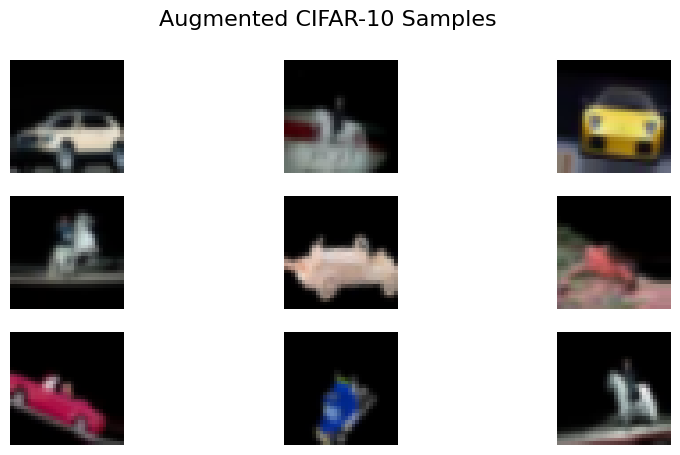

In [6]:
datagen = ImageDataGenerator(rotation_range=15,
                             width_shift_range=0.1,
                             height_shift_range=0.1,
                             horizontal_flip=True)

# Generate augmented samples
sample_imgs = next(datagen.flow(x_train[:9], batch_size=9))

plt.figure(figsize=(10, 5))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(sample_imgs[i])
    plt.axis("off")
plt.suptitle("Augmented CIFAR-10 Samples", fontsize=16)
plt.show()


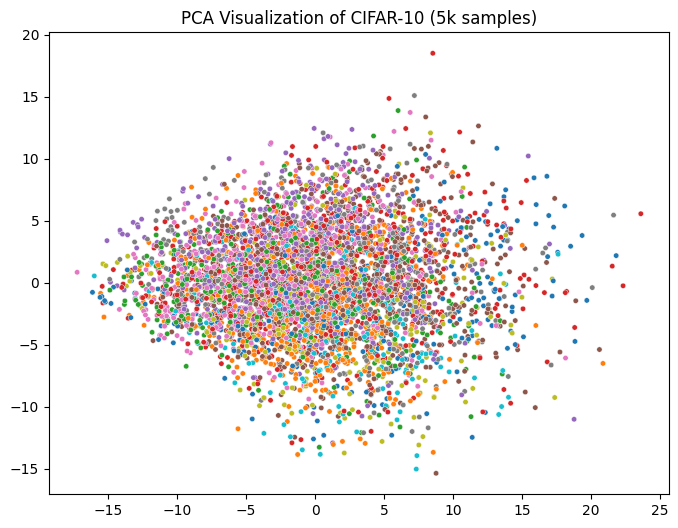

In [7]:
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_train_flat[:5000])  # sample 5k for speed
plt.figure(figsize=(8, 6))
sns.scatterplot(x=x_pca[:,0], y=x_pca[:,1], hue=y_train[:5000].flatten(),
                palette="tab10", s=15, legend=False)
plt.title("PCA Visualization of CIFAR-10 (5k samples)")
plt.show()


In [8]:
print("\n=== Extended EDA & Data Preparation Summary ===")
print(f"Training Images: {x_train.shape[0]}")
print(f"Test Images: {x_test.shape[0]}")
print("Image Size:", x_train.shape[1:])
print("Class Labels:", class_names)
print("\n✔ Cleaning done: duplicates, constant images, outliers, denoising")
print("✔ Normalization applied (0–1 scale)")
print("✔ Data ready in two formats (Flattened & Image tensors)")
print("✔ Extra: EDA (color distributions, pixel stats, PCA, augmentation preview)")



=== Extended EDA & Data Preparation Summary ===
Training Images: 49998
Test Images: 10000
Image Size: (32, 32, 3)
Class Labels: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

✔ Cleaning done: duplicates, constant images, outliers, denoising
✔ Normalization applied (0–1 scale)
✔ Data ready in two formats (Flattened & Image tensors)
✔ Extra: EDA (color distributions, pixel stats, PCA, augmentation preview)


In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
from sklearn.metrics import mean_squared_error

In [10]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(trainset, batch_size=128, shuffle=True)
test_loader = DataLoader(testset, batch_size=128, shuffle=False)

classes = ["airplane","automobile","bird","cat","deer",
           "dog","frog","horse","ship","truck"]

print("Train size:", len(trainset), " Test size:", len(testset))

100%|██████████| 170M/170M [08:22<00:00, 340kB/s]


Train size: 50000  Test size: 10000


In [11]:
class ConvAutoencoder(nn.Module):
    def __init__(self):
        super(ConvAutoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 128, 3, stride=2, padding=1),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 3, stride=2, padding=1, output_padding=1),
            nn.Tanh()
        )
    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ConvAutoencoder().to(device)

In [12]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [13]:
num_epochs = 15
train_losses, test_losses = [], []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for imgs, _ in train_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        loss = criterion(outputs, imgs)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    train_losses.append(running_loss/len(train_loader))

    model.eval()
    test_loss = 0.0
    with torch.no_grad():
        for imgs, _ in test_loader:
            imgs = imgs.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, imgs)
            test_loss += loss.item()
    test_losses.append(test_loss/len(test_loader))

    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_losses[-1]:.4f}, Test Loss: {test_losses[-1]:.4f}")

Epoch 1/15, Train Loss: 0.0444, Test Loss: 0.0189
Epoch 2/15, Train Loss: 0.0147, Test Loss: 0.0120
Epoch 3/15, Train Loss: 0.0107, Test Loss: 0.0095
Epoch 4/15, Train Loss: 0.0085, Test Loss: 0.0075
Epoch 5/15, Train Loss: 0.0072, Test Loss: 0.0067
Epoch 6/15, Train Loss: 0.0064, Test Loss: 0.0062
Epoch 7/15, Train Loss: 0.0059, Test Loss: 0.0053
Epoch 8/15, Train Loss: 0.0053, Test Loss: 0.0052
Epoch 9/15, Train Loss: 0.0050, Test Loss: 0.0045
Epoch 10/15, Train Loss: 0.0046, Test Loss: 0.0042
Epoch 11/15, Train Loss: 0.0044, Test Loss: 0.0040
Epoch 12/15, Train Loss: 0.0041, Test Loss: 0.0037
Epoch 13/15, Train Loss: 0.0038, Test Loss: 0.0037
Epoch 14/15, Train Loss: 0.0037, Test Loss: 0.0037
Epoch 15/15, Train Loss: 0.0036, Test Loss: 0.0033


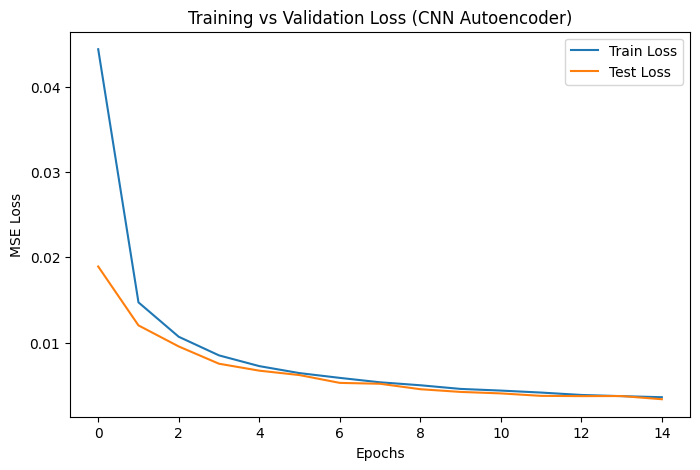

In [14]:
plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.title("Training vs Validation Loss (CNN Autoencoder)")
plt.legend()
plt.show()

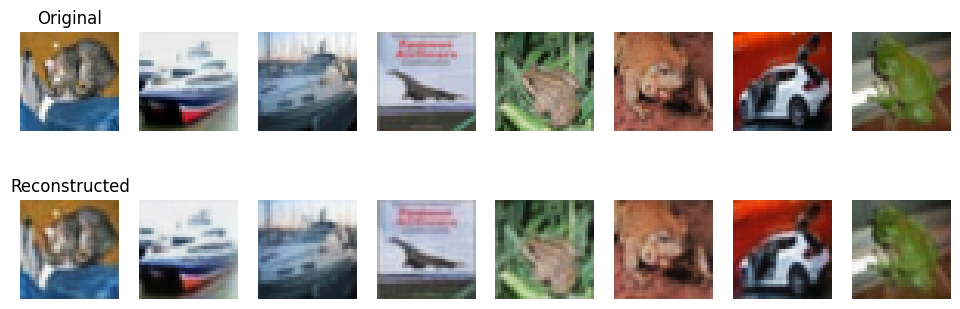

In [15]:
dataiter = iter(test_loader)
images, _ = next(dataiter)
with torch.no_grad():
    images = images.to(device)
    outputs = model(images)
images = images.cpu().numpy()
outputs = outputs.cpu().numpy()

plt.figure(figsize=(12,4))
for i in range(8):
    ax = plt.subplot(2, 8, i+1)
    plt.imshow(np.transpose((images[i]*0.5+0.5), (1,2,0)))
    plt.axis("off")
    if i == 0: ax.set_title("Original")
    ax = plt.subplot(2, 8, i+1+8)
    plt.imshow(np.transpose((outputs[i]*0.5+0.5), (1,2,0)))
    plt.axis("off")
    if i == 0: ax.set_title("Reconstructed")
plt.show()

In [17]:
start = time.time()
all_images = []
all_outputs = []
with torch.no_grad():
    for imgs, _ in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        all_images.append(imgs.cpu().numpy())
        all_outputs.append(outputs.cpu().numpy())
end = time.time()
print("Inference time on test set:", round(end-start,2), "seconds")

# Concatenate all batches
all_images = np.concatenate(all_images, axis=0)
all_outputs = np.concatenate(all_outputs, axis=0)

test_mse = mean_squared_error(
    all_images.reshape(len(all_images), -1),
    all_outputs.reshape(len(all_outputs), -1)
)
print("Reconstruction MSE on the entire test set:", test_mse)

Inference time on test set: 7.75 seconds
Reconstruction MSE on the entire test set: 0.003349918872117996


In [18]:
# --- Appended setup: imports, reproducibility ---
import os, random, time
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models, losses, optimizers
print('TensorFlow version:', tf.__version__)
seed = 42
np.random.seed(seed)
tf.random.set_seed(seed)
random.seed(seed)
# Ensure inline plots
%matplotlib inline

TensorFlow version: 2.19.0


In [19]:
# Load CIFAR-10 if not already present
try:
    x_train, y_train, x_test, y_test
    print('Dataset variables already present; skipping load.')
except NameError:
    from tensorflow.keras.datasets import cifar10
    (x_train, y_train), (x_test, y_test) = cifar10.load_data()
    x_train = x_train.astype('float32') / 255.0
    x_test = x_test.astype('float32') / 255.0
    print('Loaded CIFAR-10:', x_train.shape, x_test.shape)

Dataset variables already present; skipping load.


In [20]:
# Vanilla Autoencoder (Dense) - appended implementation
input_shape = (32,32,3)
flat_dim = 32*32*3
from tensorflow.keras import layers, models

def build_vanilla_ae(latent_dim=512):
    inp = layers.Input(shape=input_shape)
    x = layers.Flatten()(inp)
    x = layers.Dense(1024, activation='relu')(x)
    x = layers.Dense(512, activation='relu')(x)
    encoded = layers.Dense(latent_dim, activation='relu', name='encoded')(x)
    x = layers.Dense(512, activation='relu')(encoded)
    x = layers.Dense(1024, activation='relu')(x)
    x = layers.Dense(flat_dim, activation='sigmoid')(x)
    out = layers.Reshape(input_shape)(x)
    model = models.Model(inp, out, name='vanilla_ae_appended')
    return model

vanilla_ae_app = build_vanilla_ae(latent_dim=512)
vanilla_ae_app.compile(optimizer='adam', loss='mse')
vanilla_ae_app.summary()

Model: "vanilla_ae_appended"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │     3,146,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoded (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 3072)           │     3,148,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 32, 32, 3)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,870,976 (30.03 MB)

 Trainable params: 7,870,976 (30.03 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
# Train vanilla AE (appended) - set epochs modestly; increase for final runs
EPOCHS_VANILLA = 10
BATCH_SIZE = 256
history_vanilla_app = vanilla_ae_app.fit(x_train, x_train, epochs=EPOCHS_VANILLA, batch_size=BATCH_SIZE, validation_data=(x_test,x_test))

Epoch 1/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 68s 332ms/step - loss: 0.0465 - val_loss: 0.0254
Epoch 2/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 64s 329ms/step - loss: 0.0240 - val_loss: 0.0218
Epoch 3/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 80s 319ms/step - loss: 0.0207 - val_loss: 0.0188
Epoch 4/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 82s 320ms/step - loss: 0.0177 - val_loss: 0.0170
Epoch 5/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 63s 319ms/step - loss: 0.0163 - val_loss: 0.0157
Epoch 6/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 63s 320ms/step - loss: 0.0153 - val_loss: 0.0147
Epoch 7/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 82s 318ms/step - loss: 0.0144 - val_loss: 0.0140
Epoch 8/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 81s 314ms/step - loss: 0.0137 - val_loss: 0.0136
Epoch 9/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 62s 318ms/step - loss: 0.0130 - val_loss: 0.0132
Epoch 10/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 81s 314ms/step - loss: 0.0127 - val_loss: 0.0126


Text(0.5, 1.0, 'Vanilla AE Loss')

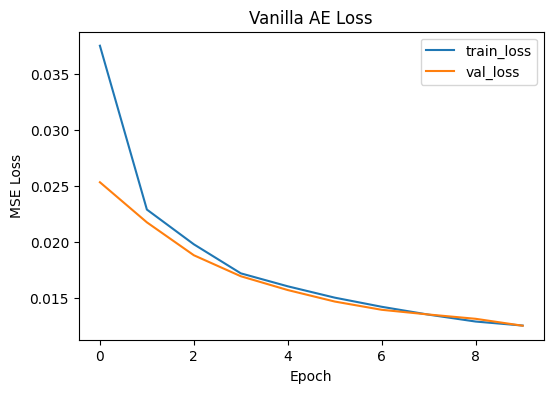

In [22]:
# Plot training loss for vanilla AE
plt.figure(figsize=(6,4))
plt.plot(history_vanilla_app.history['loss'], label='train_loss')
plt.plot(history_vanilla_app.history['val_loss'], label='val_loss')
plt.xlabel('Epoch'); plt.ylabel('MSE Loss'); plt.legend(); plt.title('Vanilla AE Loss')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
Vanilla AE MSE: 0.011212983 PSNR: 19.488362367124484


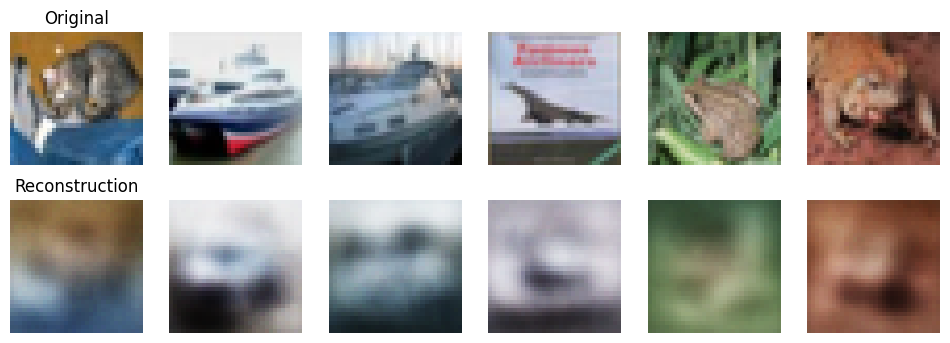

In [23]:
# Reconstructions and MSE/PSNR functions
from skimage.metrics import peak_signal_noise_ratio as psnr
def compute_mse(a,b): return np.mean((a-b)**2)
def compute_psnr(a,b): return psnr((a*255).astype(np.uint8), (b*255).astype(np.uint8), data_range=255)

# Show sample reconstructions
n=6
samples = x_test[:n]
recon = vanilla_ae_app.predict(samples)
plt.figure(figsize=(12,4))
for i in range(n):
    plt.subplot(2,n,i+1); plt.imshow(samples[i]); plt.axis('off');
    if i==0: plt.title('Original')
    plt.subplot(2,n,n+i+1); plt.imshow(recon[i]); plt.axis('off');
    if i==0: plt.title('Reconstruction')
print('Vanilla AE MSE:', compute_mse(samples, recon), 'PSNR:', compute_psnr(samples, recon))

In [24]:
# Convolutional Autoencoder (appended)
from tensorflow.keras import layers, models
def build_cnn_ae(latent_dim=256):
    inp = layers.Input(shape=input_shape)
    x = layers.Conv2D(32, 3, activation='relu', padding='same', strides=2)(inp)  # 16x16x32
    x = layers.Conv2D(64, 3, activation='relu', padding='same', strides=2)(x)    # 8x8x64
    x = layers.Conv2D(128, 3, activation='relu', padding='same', strides=2)(x)   # 4x4x128
    x = layers.Flatten()(x)
    encoded = layers.Dense(latent_dim, activation='relu')(x)
    x = layers.Dense(4*4*128, activation='relu')(encoded)
    x = layers.Reshape((4,4,128))(x)
    x = layers.Conv2DTranspose(128, 3, strides=2, padding='same', activation='relu')(x) # 8x8
    x = layers.Conv2DTranspose(64, 3, strides=2, padding='same', activation='relu')(x)  # 16x16
    x = layers.Conv2DTranspose(32, 3, strides=2, padding='same', activation='relu')(x)  # 32x32
    out = layers.Conv2D(3, 3, activation='sigmoid', padding='same')(x)
    model = models.Model(inp, out, name='cnn_ae_appended')
    return model

cnn_ae_app = build_cnn_ae(latent_dim=256)
cnn_ae_app.compile(optimizer='adam', loss='mse')
cnn_ae_app.summary()

Model: "cnn_ae_appended"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 16, 16, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 2048)           │       526,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 8, 8, 128)      │       147,584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 16, 16, 64)     │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 32, 32, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,384,835 (5.28 MB)

 Trainable params: 1,384,835 (5.28 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
# Train CNN AE (appended)
EPOCHS_CNN = 15
history_cnn_app = cnn_ae_app.fit(x_train, x_train, epochs=EPOCHS_CNN, batch_size=256, validation_data=(x_test,x_test))

Epoch 1/15
196/196 ━━━━━━━━━━━━━━━━━━━━ 214s 1s/step - loss: 0.0432 - val_loss: 0.0173
Epoch 2/15
196/196 ━━━━━━━━━━━━━━━━━━━━ 263s 1s/step - loss: 0.0163 - val_loss: 0.0148
Epoch 3/15
196/196 ━━━━━━━━━━━━━━━━━━━━ 253s 1s/step - loss: 0.0145 - val_loss: 0.0118
Epoch 4/15
196/196 ━━━━━━━━━━━━━━━━━━━━ 260s 1s/step - loss: 0.0112 - val_loss: 0.0102
Epoch 5/15
196/196 ━━━━━━━━━━━━━━━━━━━━ 209s 1s/step - loss: 0.0097 - val_loss: 0.0091
Epoch 6/15
196/196 ━━━━━━━━━━━━━━━━━━━━ 200s 1s/step - loss: 0.0088 - val_loss: 0.0083
Epoch 7/15
196/196 ━━━━━━━━━━━━━━━━━━━━ 209s 1s/step - loss: 0.0083 - val_loss: 0.0078
Epoch 8/15
196/196 ━━━━━━━━━━━━━━━━━━━━ 209s 1s/step - loss: 0.0079 - val_loss: 0.0079
Epoch 9/15
196/196 ━━━━━━━━━━━━━━━━━━━━ 210s 1s/step - loss: 0.0078 - val_loss: 0.0074
Epoch 10/15
196/196 ━━━━━━━━━━━━━━━━━━━━ 203s 1s/step - loss: 0.0070 - val_loss: 0.0069
Epoch 11/15
196/196 ━━━━━━━━━━━━━━━━━━━━ 263s 1s/step - loss: 0.0067 - val_loss: 0.0066
Epoch 12/15
196/196 ━━━━━━━━━━━━━━━━━━━━ 

Text(0.5, 1.0, 'CNN AE Loss')

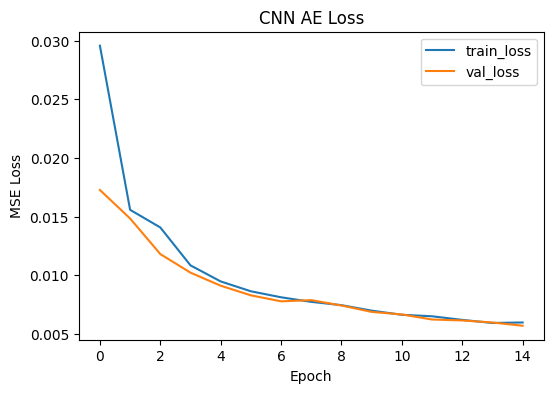

In [26]:
# Plot CNN training loss
plt.figure(figsize=(6,4))
plt.plot(history_cnn_app.history['loss'], label='train_loss')
plt.plot(history_cnn_app.history['val_loss'], label='val_loss')
plt.xlabel('Epoch'); plt.ylabel('MSE Loss'); plt.legend(); plt.title('CNN AE Loss')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
CNN AE MSE: 0.0056903493 PSNR: 22.441128473956052


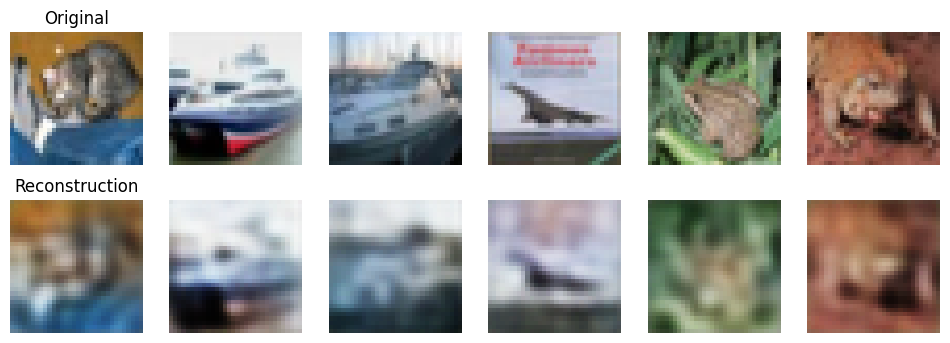

In [27]:
# CNN reconstructions and MSE/PSNR
n=6
samples = x_test[:n]
recon_cnn = cnn_ae_app.predict(samples)
plt.figure(figsize=(12,4))
for i in range(n):
    plt.subplot(2,n,i+1); plt.imshow(samples[i]); plt.axis('off');
    if i==0: plt.title('Original')
    plt.subplot(2,n,n+i+1); plt.imshow(recon_cnn[i]); plt.axis('off');
    if i==0: plt.title('Reconstruction')
print('CNN AE MSE:', compute_mse(samples, recon_cnn), 'PSNR:', compute_psnr(samples, recon_cnn))

In [28]:
# VAE (appended)
import tensorflow as tf
from tensorflow.keras import layers, Model
latent_dim = 128

# Encoder
encoder_inputs = layers.Input(shape=input_shape)
x = layers.Conv2D(32, 3, strides=2, padding='same', activation='relu')(encoder_inputs)
x = layers.Conv2D(64, 3, strides=2, padding='same', activation='relu')(x)
x = layers.Conv2D(128, 3, strides=2, padding='same', activation='relu')(x)
x = layers.Flatten()(x)
x = layers.Dense(256, activation='relu')(x)
z_mean = layers.Dense(latent_dim, name='z_mean')(x)
z_logvar = layers.Dense(latent_dim, name='z_logvar')(x)

def sampling(args):
    z_mean, z_logvar = args
    batch = tf.shape(z_mean)[0]
    dim = tf.shape(z_mean)[1]
    epsilon = tf.random.normal(shape=(batch, dim))
    return z_mean + tf.exp(0.5 * z_logvar) * epsilon

z = layers.Lambda(sampling, output_shape=(latent_dim,), name='z')([z_mean, z_logvar])

# Decoder
decoder_inputs = layers.Input(shape=(latent_dim,))
x = layers.Dense(4*4*128, activation='relu')(decoder_inputs)
x = layers.Reshape((4,4,128))(x)
x = layers.Conv2DTranspose(128, 3, strides=2, padding='same', activation='relu')(x)
x = layers.Conv2DTranspose(64, 3, strides=2, padding='same', activation='relu')(x)
x = layers.Conv2DTranspose(32, 3, strides=2, padding='same', activation='relu')(x)
decoder_outputs = layers.Conv2D(3, 3, activation='sigmoid', padding='same')(x)

encoder_app = Model(encoder_inputs, [z_mean, z_logvar, z], name='encoder_app')
decoder_app = Model(decoder_inputs, decoder_outputs, name='decoder_app')

# Custom VAE
flat_dim = 32*32*3
reconstruction_loss_fn = tf.keras.losses.MeanSquaredError()

class VAEApp(Model):
    def __init__(self, encoder, decoder, beta=1.0, **kwargs):
        super(VAEApp, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.beta = beta
        self.recon_loss_fn = tf.keras.losses.MeanSquaredError()
    def compile(self, optimizer):
        super(VAEApp, self).compile()
        self.optimizer = optimizer
    def train_step(self, data):
        x = data
        with tf.GradientTape() as tape:
            z_mean, z_logvar, z = self.encoder(x)
            x_decoded = self.decoder(z)
            recon_loss = self.recon_loss_fn(tf.reshape(x, (-1, flat_dim)), tf.reshape(x_decoded, (-1, flat_dim)))
            kl_loss = -0.5 * tf.reduce_mean(1 + z_logvar - tf.square(z_mean) - tf.exp(z_logvar))
            total_loss = recon_loss + self.beta * kl_loss
        grads = tape.gradient(total_loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))
        return {'loss': total_loss, 'recon_loss': recon_loss, 'kl_loss': kl_loss}
    def test_step(self, data):
        x = data
        z_mean, z_logvar, z = self.encoder(x)
        x_decoded = self.decoder(z)
        recon_loss = self.recon_loss_fn(tf.reshape(x, (-1, flat_dim)), tf.reshape(x_decoded, (-1, flat_dim)))
        kl_loss = -0.5 * tf.reduce_mean(1 + z_logvar - tf.square(z_mean) - tf.exp(z_logvar))
        total_loss = recon_loss + self.beta * kl_loss
        return {'loss': total_loss, 'recon_loss': recon_loss, 'kl_loss': kl_loss}

vae_app = VAEApp(encoder_app, decoder_app, beta=1.0, name='vae_app')
vae_app.compile(optimizer=tf.keras.optimizers.Adam())
vae_app.build((None,)+input_shape)
vae_app.summary()

Model: "vae_app"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_app (Functional)        │ ((None, 128), (None,   │       683,584 │
│                                 │ 128), (None, 128))     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_app (Functional)        │ (None, 32, 32, 3)      │       504,899 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,188,483 (4.53 MB)

 Trainable params: 1,188,483 (4.53 MB)

 Non-trainable params: 0 (0.00 B)

In [29]:
# Train VAE (appended)
EPOCHS_VAE = 15
history_vae_app = vae_app.fit(x_train, epochs=EPOCHS_VAE, batch_size=256, validation_data=(x_test,))

Epoch 1/15
196/196 ━━━━━━━━━━━━━━━━━━━━ 222s 1s/step - kl_loss: 1.5824e-04 - loss: 0.0620 - recon_loss: 0.0618 - val_kl_loss: 0.0012 - val_loss: 0.0695 - val_recon_loss: 0.0683
Epoch 2/15
196/196 ━━━━━━━━━━━━━━━━━━━━ 209s 1s/step - kl_loss: 0.0045 - loss: 0.0576 - recon_loss: 0.0530 - val_kl_loss: 0.0061 - val_loss: 0.0725 - val_recon_loss: 0.0664
Epoch 3/15
196/196 ━━━━━━━━━━━━━━━━━━━━ 202s 1s/step - kl_loss: 0.0058 - loss: 0.0563 - recon_loss: 0.0505 - val_kl_loss: 0.0058 - val_loss: 0.0623 - val_recon_loss: 0.0565
Epoch 4/15
196/196 ━━━━━━━━━━━━━━━━━━━━ 210s 1s/step - kl_loss: 0.0059 - loss: 0.0562 - recon_loss: 0.0503 - val_kl_loss: 0.0057 - val_loss: 0.0640 - val_recon_loss: 0.0583
Epoch 5/15
196/196 ━━━━━━━━━━━━━━━━━━━━ 202s 1s/step - kl_loss: 0.0059 - loss: 0.0562 - recon_loss: 0.0503 - val_kl_loss: 0.0060 - val_loss: 0.0618 - val_recon_loss: 0.0558
Epoch 6/15
196/196 ━━━━━━━━━━━━━━━━━━━━ 261s 1s/step - kl_loss: 0.0059 - loss: 0.0561 - recon_loss: 0.0502 - val_kl_loss: 0.0054 - 

Text(0.5, 1.0, 'VAE Loss Components')

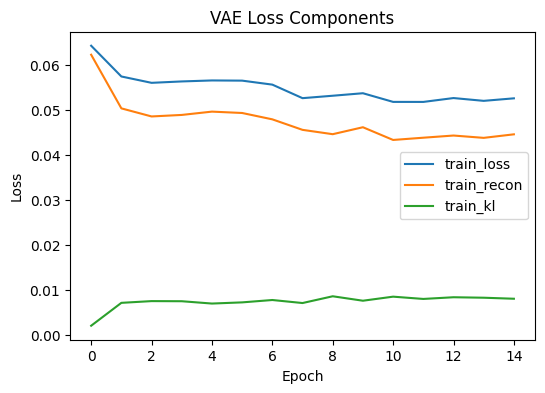

In [30]:
# Plot VAE losses
plt.figure(figsize=(6,4))
plt.plot(history_vae_app.history['loss'], label='train_loss')
# VAE custom training returns metrics; Keras may store names as 'recon_loss' and 'kl_loss' in history
if 'recon_loss' in history_vae_app.history:
    plt.plot(history_vae_app.history['recon_loss'], label='train_recon')
if 'kl_loss' in history_vae_app.history:
    plt.plot(history_vae_app.history['kl_loss'], label='train_kl')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.title('VAE Loss Components')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 410ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step
VAE MSE: 0.03827319 PSNR: 14.182668408447292


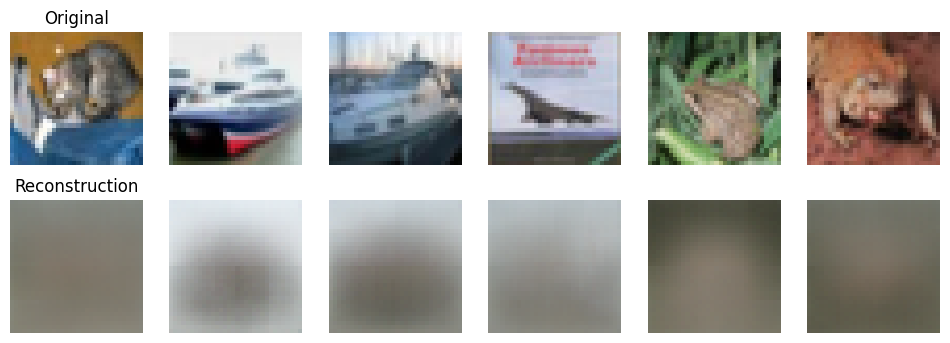

In [31]:
# VAE reconstructions and metrics
n=6
samples = x_test[:n]
# For VAE, get reconstructed outputs by encoding then decoding sampled z
z_mean, z_logvar, z = encoder_app.predict(samples)
recon_vae = decoder_app.predict(z)
plt.figure(figsize=(12,4))
for i in range(n):
    plt.subplot(2,n,i+1); plt.imshow(samples[i]); plt.axis('off');
    if i==0: plt.title('Original')
    plt.subplot(2,n,n+i+1); plt.imshow(recon_vae[i]); plt.axis('off');
    if i==0: plt.title('Reconstruction')
print('VAE MSE:', compute_mse(samples, recon_vae), 'PSNR:', compute_psnr(samples, recon_vae))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


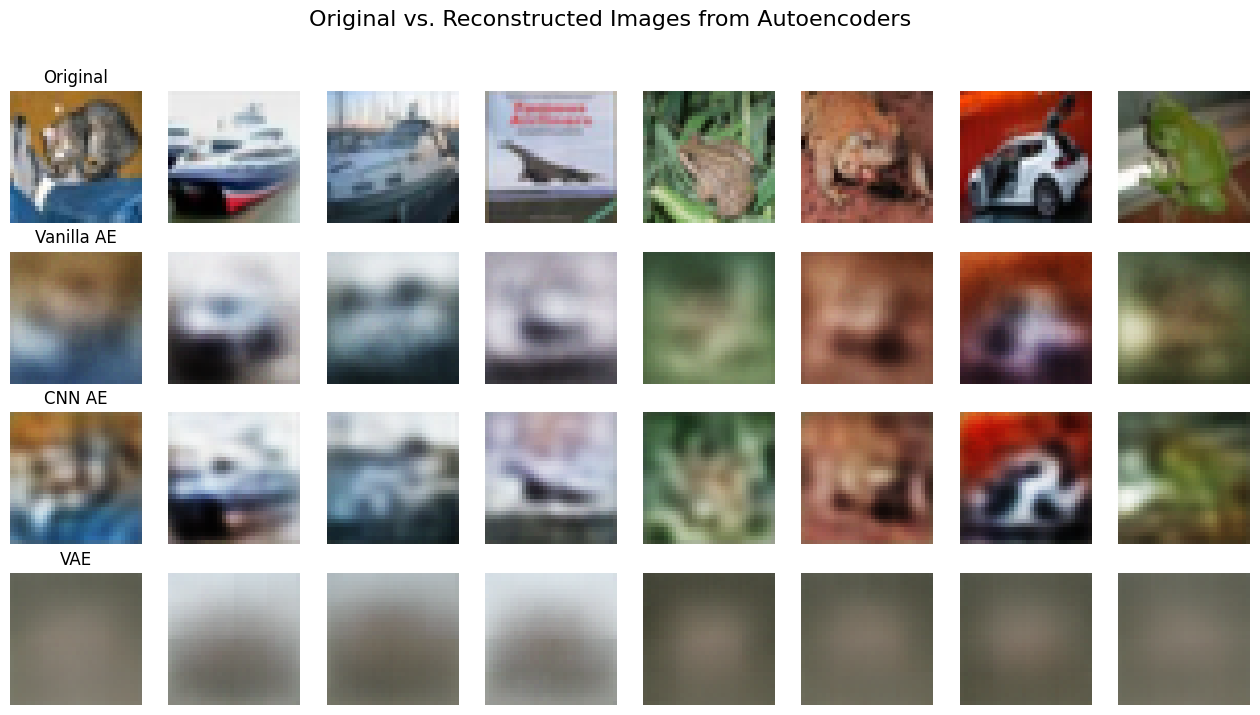

In [35]:
# Visualize original and reconstructed images from all models
n = 8 # Number of images to display
samples = x_test[:n]

# Get reconstructions
recon_vanilla = vanilla_ae_app.predict(samples)
recon_cnn = cnn_ae_app.predict(samples)
z_mean, z_logvar, z = encoder_app.predict(samples)
recon_vae = decoder_app.predict(z)


plt.figure(figsize=(16, 8))
for i in range(n):
    # Original
    ax = plt.subplot(4, n, i + 1)
    plt.imshow(samples[i])
    plt.axis("off")
    if i == 0:
        ax.set_title("Original")

    # Vanilla AE
    ax = plt.subplot(4, n, i + 1 + n)
    plt.imshow(recon_vanilla[i])
    plt.axis("off")
    if i == 0:
        ax.set_title("Vanilla AE")

    # CNN AE
    ax = plt.subplot(4, n, i + 1 + 2 * n)
    plt.imshow(recon_cnn[i])
    plt.axis("off")
    if i == 0:
        ax.set_title("CNN AE")

    # VAE
    ax = plt.subplot(4, n, i + 1 + 3 * n)
    plt.imshow(recon_vae[i])
    plt.axis("off")
    if i == 0:
        ax.set_title("VAE")

plt.suptitle("Original vs. Reconstructed Images from Autoencoders", fontsize=16)
plt.show()

In [32]:
# Compute metrics and inference time
import time, pandas as pd
def eval_model_predict(model, samples, is_vae=False, encoder=None, decoder=None):
    start = time.time()
    if is_vae:
        z_mean, z_logvar, z = encoder.predict(samples)
        recon = decoder.predict(z)
    else:
        recon = model.predict(samples)
    end = time.time()
    inf_time = (end - start) / len(samples)
    mse_val = compute_mse(samples, recon)
    psnr_val = compute_psnr(samples, recon)
    return mse_val, psnr_val, inf_time

n_eval = 100
samples_eval = x_test[:n_eval]

m_van, p_van, t_van = eval_model_predict(vanilla_ae_app, samples_eval)
m_cnn, p_cnn, t_cnn = eval_model_predict(cnn_ae_app, samples_eval)
m_vae_val, p_vae, t_vae = eval_model_predict(None, samples_eval, is_vae=True, encoder=encoder_app, decoder=decoder_app)

df = pd.DataFrame({
    'model': ['vanilla','cnn','vae'],
    'mse': [m_van, m_cnn, m_vae_val],
    'psnr': [p_van, p_cnn, p_vae],
    'inf_time_s': [t_van, t_cnn, t_vae]
})
df

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


,model,mse,psnr,inf_time_s
0,vanilla,0.012637,18.970311,0.012435
1,cnn,0.005805,22.352517,0.015430
2,vae,0.043604,13.607238,0.014772


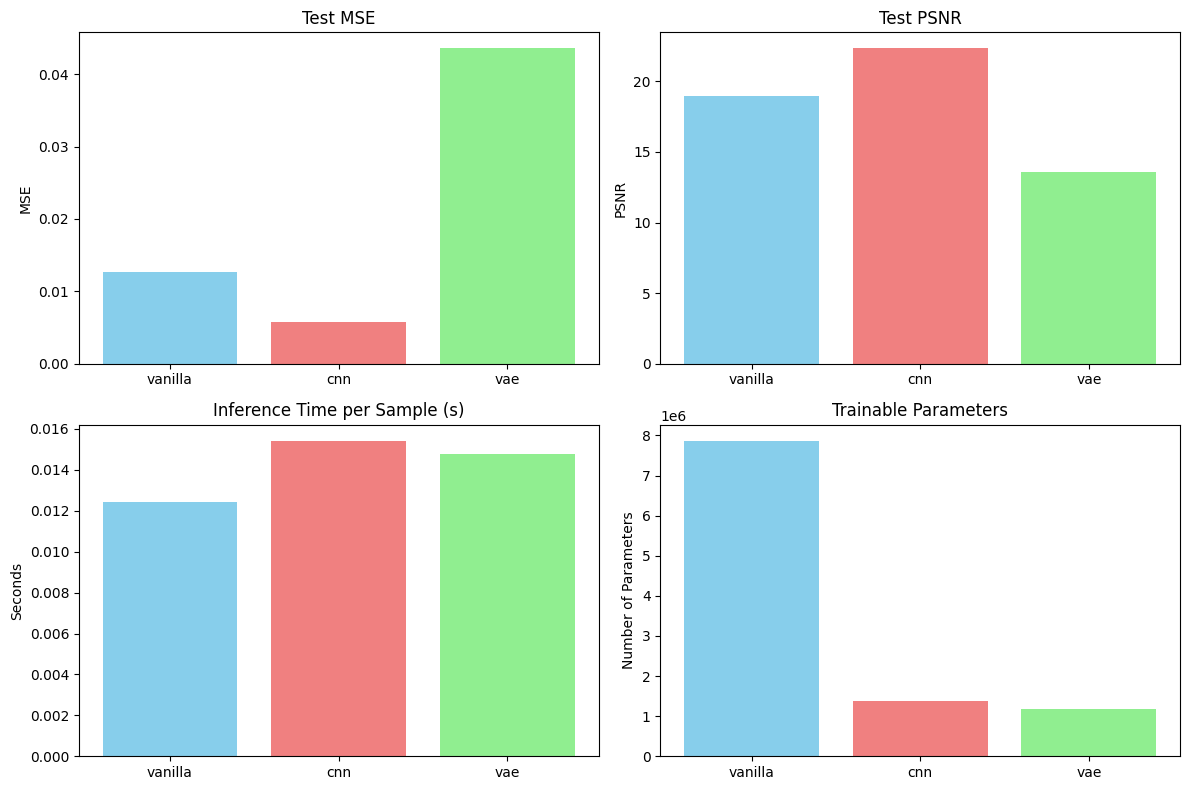

In [58]:
import matplotlib.pyplot as plt

# Define colors for each model
colors = ['skyblue', 'lightcoral', 'lightgreen']
models = df_plot.index  # ['vanilla', 'cnn', 'vae']

# Metrics to plot as bars
metrics = ['mse', 'psnr', 'inf_time_s', 'trainable_params']
titles = ['Test MSE', 'Test PSNR', 'Inference Time per Sample (s)', 'Trainable Parameters']
y_labels = ['MSE', 'PSNR', 'Seconds', 'Number of Parameters']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))  # 2 rows, 2 columns
axes = axes.flatten()

for i, metric in enumerate(metrics):
    axes[i].bar(models, df_plot[metric], color=colors)
    axes[i].set_title(titles[i])
    axes[i].set_ylabel(y_labels[i])
    axes[i].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


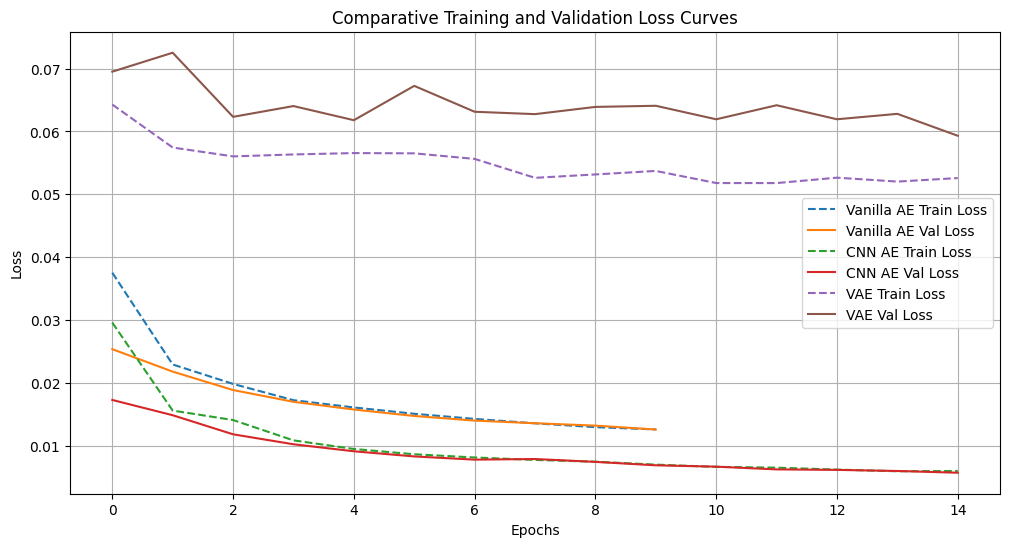

In [38]:
# Compare training/validation loss curves
plt.figure(figsize=(12, 6))

# Plot Vanilla AE loss
plt.plot(history_vanilla_app.history['loss'], label='Vanilla AE Train Loss', linestyle='--')
plt.plot(history_vanilla_app.history['val_loss'], label='Vanilla AE Val Loss')

# Plot CNN AE loss

if 'history_cnn_app' in locals():
    plt.plot(history_cnn_app.history['loss'], label='CNN AE Train Loss', linestyle='--')
    plt.plot(history_cnn_app.history['val_loss'], label='CNN AE Val Loss')
else:
    print("CNN AE history not found. Please run the CNN AE training cell.")

# Plot VAE loss
if 'history_vae_app' in locals():
    # VAE history might store total loss, or recon/kl separately
    if 'loss' in history_vae_app.history:
        plt.plot(history_vae_app.history['loss'], label='VAE Train Loss', linestyle='--')
    if 'val_loss' in history_vae_app.history:
         plt.plot(history_vae_app.history['val_loss'], label='VAE Val Loss')
    elif 'val_recon_loss' in history_vae_app.history: # Check for recon loss if total not available
         plt.plot(history_vae_app.history['val_recon_loss'], label='VAE Val Recon Loss')

else:
    print("VAE history not found. Please run the VAE training cell.")


plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Comparative Training and Validation Loss Curves")
plt.legend()
plt.grid(True)
plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
Inference Time per sample (seconds):
Vanilla AE: 0.003941
CNN AE: 0.003894
VAE: 0.005443


In [57]:

results = {}

# Populate results dictionary from df_plot and history objects
for index, row in df_plot.iterrows():
    model_name = index
    results[model_name] = {
        'test_mse': row['mse'],
        'psnr': row['psnr'],
        'training_time': row['train_time_s'], # Using placeholder 0 if not accurately measured
        'param_count': row['trainable_params'],
        'final_train_loss': row['final_train_loss'],
        'train_losses': history_vanilla_app.history['loss'] if model_name == 'vanilla' else (history_cnn_app.history['loss'] if model_name == 'cnn' else history_vae_app.history.get('loss', history_vae_app.history.get('recon_loss'))) # Get full loss history
    }


# Comprehensive Analysis Report
print("\n" + "="*80)
print("COMPREHENSIVE COMPARATIVE ANALYSIS REPORT")
print("="*80)

print("\n1. PERFORMANCE RANKING (by Test MSE - lower is better):")
sorted_models = sorted(results.items(), key=lambda x: x[1]['test_mse'])
for i, (name, result) in enumerate(sorted_models, 1):
    print(f"   {i}. {name}: {result['test_mse']:.6f}")

print("\n2. EFFICIENCY RANKING (by Training Time - lower is better):")
sorted_by_time = sorted(results.items(), key=lambda x: x[1]['training_time'])
for i, (name, result) in enumerate(sorted_by_time, 1):
    print(f"   {i}. {name}: {result['training_time']:.2f} seconds")

print("\n3. MODEL COMPLEXITY (by Parameter Count):")
sorted_by_params = sorted(results.items(), key=lambda x: x[1]['param_count'])
for i, (name, result) in enumerate(sorted_by_params, 1):
    print(f"   {i}. {name}: {result['param_count']:,} parameters")

print("\n4. DETAILED MODEL ANALYSIS:")
for name, result in results.items():
    print(f"\n   {name.upper()} AUTOENCODER:")
    print(f"   - Test MSE: {result['test_mse']:.6f}")
    print(f"   - Training Time: {result['training_time']:.2f} seconds")
    print(f"   - Parameters: {result['param_count']:,}")
    print(f"   - Final Training Loss: {result['final_train_loss']:.4f}")

    # Calculate performance per parameter
    # Avoid division by zero if MSE is exactly 0 (highly unlikely but good practice)
    perf_per_param = result['param_count'] / (1 / result['test_mse']) if result['test_mse'] != 0 else float('inf')
    print(f"   - Efficiency Score (Params / (1/MSE)): {perf_per_param:.2e}")

print("\n5. RECOMMENDATIONS:")
best_performance = min(results.items(), key=lambda x: x[1]['test_mse'])
fastest_training = min(results.items(), key=lambda x: x[1]['training_time'])
# Filter out models with 0 training time if accurate measurement is needed
if all(r['training_time'] == 0 for r in results.values()):
     print("   - Fastest Training: Training times not available or are all 0.")
else:
    fastest_training = min(results.items(), key=lambda x: x[1]['training_time'] if x[1]['training_time'] > 0 else float('inf'))
    print(f"   - Fastest Training: {fastest_training[0]} ({fastest_training[1]['training_time']:.2f}s)")


most_efficient = min(results.items(), key=lambda x: x[1]['param_count'])

print(f"   - Best Performance: {best_performance[0]} (MSE: {best_performance[1]['test_mse']:.6f})")
print(f"   - Most Efficient (Parameters): {most_efficient[0]} ({most_efficient[1]['param_count']:,} params)")

print("\n" + "="*80)


COMPREHENSIVE COMPARATIVE ANALYSIS REPORT

1. PERFORMANCE RANKING (by Test MSE - lower is better):
   1. cnn: 0.005805
   2. vanilla: 0.012637
   3. vae: 0.043604

2. EFFICIENCY RANKING (by Training Time - lower is better):
   1. vanilla: 0.00 seconds
   2. cnn: 0.00 seconds
   3. vae: 0.00 seconds

3. MODEL COMPLEXITY (by Parameter Count):
   1. vae: 1,188,483.0 parameters
   2. cnn: 1,384,835.0 parameters
   3. vanilla: 7,870,976.0 parameters

4. DETAILED MODEL ANALYSIS:

   VANILLA AUTOENCODER:
   - Test MSE: 0.012637
   - Training Time: 0.00 seconds
   - Parameters: 7,870,976.0
   - Final Training Loss: 0.0126
   - Efficiency Score (Params / (1/MSE)): 9.95e+04

   CNN AUTOENCODER:
   - Test MSE: 0.005805
   - Training Time: 0.00 seconds
   - Parameters: 1,384,835.0
   - Final Training Loss: 0.0060
   - Efficiency Score (Params / (1/MSE)): 8.04e+03

   VAE AUTOENCODER:
   - Test MSE: 0.043604
   - Training Time: 0.00 seconds
   - Parameters: 1,188,483.0
   - Final Training Loss: 0.